# DNA Dataset Usage and Preview

The repository of high-fidelity neural actors is available at:
https://dna-rendering.github.io (after signing the license agreement).  

We follow Data Reader instructions from [this issue](https://github.com/DNA-Rendering/DNA-Rendering/issues/12).

## Actors used in the paper

- **0307_07** (DNA Part 1) — hairdryer scene
- **85_07** (DNA Part 2) — table scene
- **802_05** (DNA Part 2) — shoes scene

Please download the main `.smc` file and corresponding `*_annots.smc` annotation file and place them in the following directory structure:

```
dna/
└── dna_shoes/
    ├── annotations/
    │   └── 0802_05_annots.smc
    └── main/
        └── 080205.smc
    └── point_cloud.ply  <- optional
```

DNA reader uses SMPLX to generate human point cloud that could be automatically used as initial point cloud for gaussians. You will need to download SPML body files from [here](https://smpl.is.tue.mpg.de/) and put them into `assets/body_models`. Follow the instructions from DNA authors regarding exact files to download.  

Note, for scenes like **"shoes", "table"** additional items like stool, shoes, table will be missing in initial points. You can optionally put your own point_could.ply from typical Gaussian Splatting (pre)training, where all scene elements are properly represented. It will be used by default in LumiMotion initialization then.

We train LumiMotion on shorter sequences, note we set **timesteps** in bash scripts: `bash_scripts/dna_hairdryer.sh`, `bash_scripts/dna_shoes.sh`, `bash_scripts/dna_table.sh`

## Visualisation of DNA data using smc files.

In [ ]:
import os
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm


# IF YOU RUN THIS CELL TWICE AND CWD BREAKS PLEASE RESTART KERNEL.
here = Path(os.getcwd()).resolve()
target_dir = here.parent
print(target_dir)
os.chdir(target_dir)

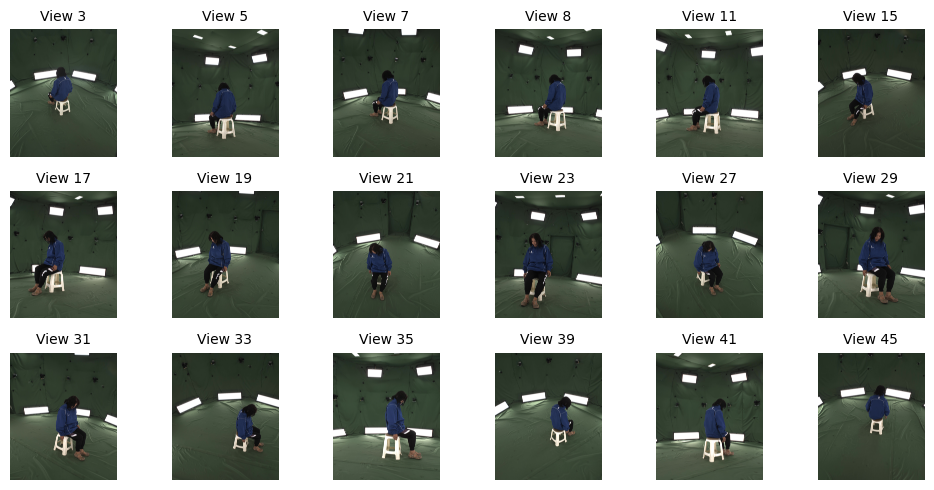

In [ ]:
from scene.SMCReader import SMCReader

# -------------------------------------------------------
# Your paths
# -------------------------------------------------------
dna_main_path  = "data/dna/802_05_shoes/main/0802_05.smc"
dna_annot_path = "data/dna/802_05_shoes/annotations/0802_05_annots.smc"

main_reader  = SMCReader(dna_main_path)
annot_reader = SMCReader(dna_annot_path)

# Frame + views you want to visualize
frame_idx = 100
view_list = [3, 5, 7, 8, 11, 15, 17, 19, 21, 23, 27, 29, 31, 33, 35, 39, 41, 45]

# -------------------------------------------------------
# Grid layout
# -------------------------------------------------------
cols = 6
rows = int(np.ceil(len(view_list) / cols))

plt.figure(figsize=(10,5))

# -------------------------------------------------------
# Loop over view IDs
# -------------------------------------------------------
for i, view_idx in enumerate(view_list):
    
    # -------- Load calibration --------
    calib = annot_reader.get_Calibration(view_idx)
    K = calib['K']
    D = calib['D']

    # -------- Load & undistort image --------
    img = main_reader.get_img("Camera_5mp", view_idx,
                              Image_type="color", Frame_id=frame_idx)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.undistort(img, K, D)

    mask = annot_reader.get_mask(view_idx, Frame_id=frame_idx)
    mask = cv.undistort(mask, K, D)
    mask = (mask.astype(np.float32) / 255.0)[..., None]

    img = img.astype(np.float32)
    img = img #* mask
    img = img.astype(np.uint8)


    # -------- Plot in grid --------
    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(img)
    ax.set_title(f"View {view_idx}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


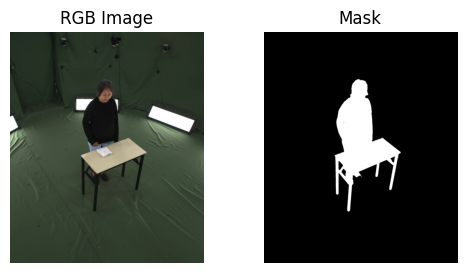

In [ ]:
import os
import numpy as np
import cv2 as cv
from PIL import Image
import matplotlib.pyplot as plt

from scene.SMCReader import SMCReader   # make sure SMCReader.py is in your working directory


# -------------------------------------------------------
# Path to your DNA .smc main file (example)
# -------------------------------------------------------
dna_main_path  = "data/dna/85_07_table/main/0085_07.smc"
dna_annot_path = "data/dna/85_07_table/annotations/0085_07_annots.smc"

# Load SMC readers
main_reader  = SMCReader(dna_main_path)
annot_reader = SMCReader(dna_annot_path)

# Pick frame and camera
frame_idx = 25
view_idx  = 27

# -------------------------------------------------------
# Load calibration (K, D, RT)
# -------------------------------------------------------
calib = annot_reader.get_Calibration(view_idx)
K = calib['K']
D = calib['D']

# -------------------------------------------------------
# Load and undistort image
# -------------------------------------------------------
img = main_reader.get_img("Camera_5mp", view_idx, Image_type="color", Frame_id=frame_idx)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = cv.undistort(img, K, D)

# -------------------------------------------------------
# Load and undistort mask
# -------------------------------------------------------
mask = annot_reader.get_mask(view_idx, Frame_id=frame_idx)
mask = cv.undistort(mask, K, D)
mask = (mask.astype(np.float32) / 255.0)[..., None]

# -------------------------------------------------------
# Combine image + mask for display
# -------------------------------------------------------
rgba = np.concatenate([img, mask * 255], axis=-1).astype(np.uint8)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.title("RGB Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()
